#### Imports

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

## Part A : build the dataset 

In [2]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})



In [3]:
students.to_csv("students.csv", index=False)
students.head()

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


## Part B: Real relationship chart

In [4]:
study_exam_r = students["study_hours_per_week"].corr(
    students["exam_score"]
)

print(f"Pearson correlation: r = {study_exam_r:.3f}")

Pearson correlation: r = 0.689


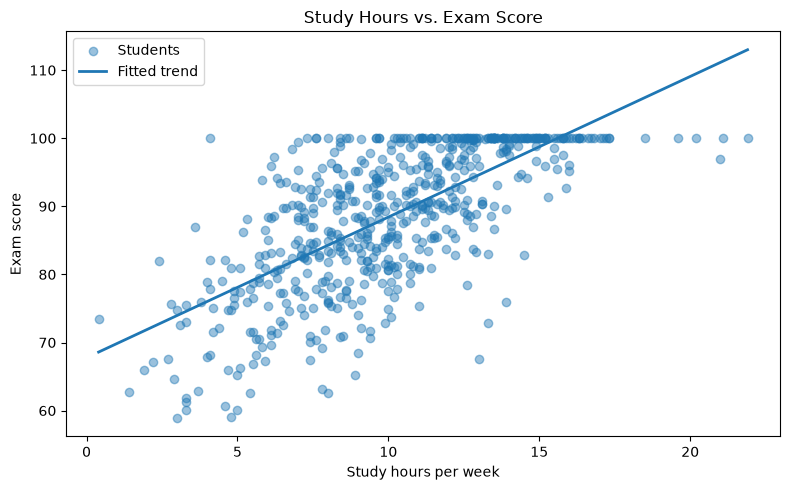

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(students["study_hours_per_week"],students["exam_score"],alpha=0.45,label="Students")

x = students["study_hours_per_week"]

z = np.polyfit(students["study_hours_per_week"],students["exam_score"],1)

trend = np.poly1d(z)

x_sorted = np.sort(x)

ax.plot(
    x_sorted,
    trend(x_sorted),
    linewidth=2,
    label="Fitted trend"
)

ax.set_title("Study Hours vs. Exam Score")
ax.set_xlabel("Study hours per week")
ax.set_ylabel("Exam score")

ax.legend()
fig.savefig("graphs/02_study_vs_score.png", dpi=150)
fig.tight_layout()
plt.show()

In [6]:
finding_study = (
    f"Study hours per week and exam score show a strong positive relationship "
    f"(Pearson r = {study_exam_r:.3f}, n = {n}): students who study more tend to score higher."
)
#print(f"Study hours show a positive relationship with exam score, "f"with Pearson r = {study_exam_r:.3f}.")
finding_study

'Study hours per week and exam score show a strong positive relationship (Pearson r = 0.689, n = 600): students who study more tend to score higher.'

In [7]:
sleep_exam_r = students["sleep_hours_per_night"].corr(students["exam_score"])
print(f"Pearson correlation: r = {sleep_exam_r:.3f}")

Pearson correlation: r = -0.022


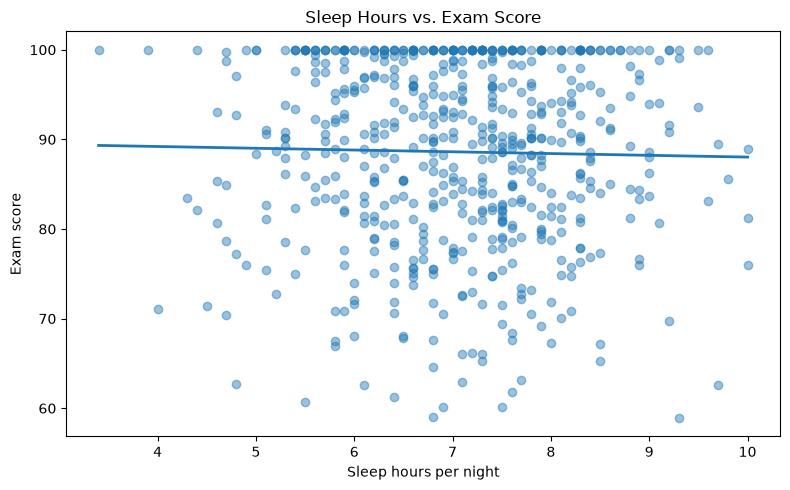

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(students["sleep_hours_per_night"],students["exam_score"],alpha=0.45)

x = students["sleep_hours_per_night"]

z = np.polyfit(students["sleep_hours_per_night"],students["exam_score"],1)

trend = np.poly1d(z)

x_sorted = np.sort(x)

ax.plot(
    x_sorted,
    trend(x_sorted),
    linewidth=2
)

ax.set_title("Sleep Hours vs. Exam Score")
ax.set_xlabel("Sleep hours per night")
ax.set_ylabel("Exam score")
fig.savefig("graphs/03_sleep_vs_score.png", dpi=150)
fig.tight_layout()
plt.show()

In [9]:
finding_sleep = (
    f"Sleep hours per night show no meaningful relationship with exam score in this dataset "
    f"(Pearson r = {sleep_exam_r:.3f}, n = {n}); this near-zero correlation is itself the finding, "
    f"not a chart that failed."
)
# print(
#     f"Sleep hours show little to no meaningful relationship "
#     f"with exam score in this dataset, with Pearson r = {sleep_exam_r:.3f}."
# )
finding_sleep

'Sleep hours per night show no meaningful relationship with exam score in this dataset (Pearson r = -0.022, n = 600); this near-zero correlation is itself the finding, not a chart that failed.'

## Part B : Genuine comparison

In [10]:
section_order = ["A", "B", "C"]
section_means = students.groupby("class_section")["exam_score"].mean().reindex(section_order)
section_means

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

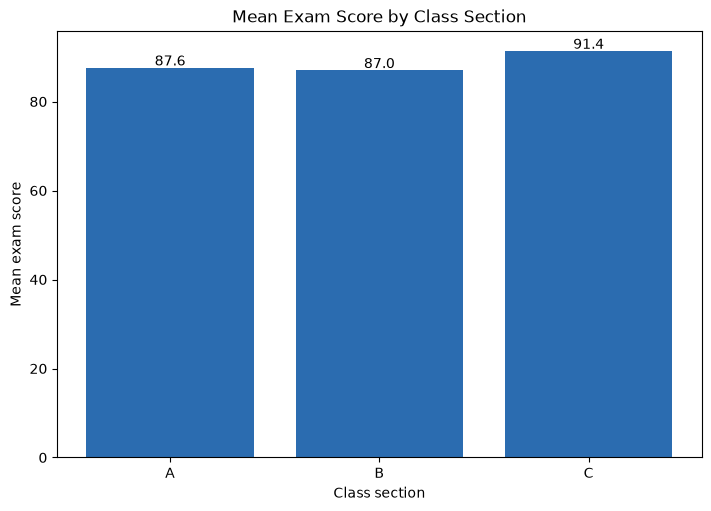

In [12]:

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")

ax.bar(
    section_order,
    section_means.values,
    color="#2b6cb0"
)

ax.set_title("Mean Exam Score by Class Section")
ax.set_xlabel("Class section")
ax.set_ylabel("Mean exam score")

for i, value in enumerate(section_means.values):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}",
        ha="center"
    )

fig.savefig("graphs/04_score_by_section.png", dpi=150)

plt.show()

finding_comparison = (
    "This is a comparison chart, not a relationship chart: class_section has no inherent "
    "numeric order, so shuffling the bars into any other order (B, A, C or C, A, B) would "
    "convey exactly the same information, which is the defining test for a categorical comparison."
)
